


DATA PREPROCESSING




In [1]:
import pandas as pd
df = pd.read_csv("traversal_cost_data.csv")
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   elevation                20000 non-null  float64
 1   avg_traffic_speed        20000 non-null  float64
 2   pollution_level          20000 non-null  float64
 3   population_density       20000 non-null  float64
 4   road_quality_index       20000 non-null  float64
 5   proximity_main_roads     20000 non-null  float64
 6   weather_condition_index  20000 non-null  float64
 7   type_of_terrain          20000 non-null  object 
 8   zone_classification      20000 non-null  object 
 9   time_of_day              20000 non-null  object 
 10  traversal_cost           20000 non-null  float64
dtypes: float64(8), object(3)
memory usage: 1.7+ MB


,elevation,avg_traffic_speed,pollution_level,population_density,road_quality_index,proximity_main_roads,weather_condition_index,traversal_cost
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,49.934472,49.938189,150.001259,2502.531482,5.483837,501.066698,5.492818,584.628553
std,28.850293,28.787989,86.646892,1434.049651,2.607363,289.363615,2.597967,441.908558
min,0.001163,0.000554,0.002530,0.650056,1.000264,0.027530,1.000512,4.830422
25%,24.988676,25.045603,75.299692,1264.093221,3.198053,248.542302,3.234048,228.932847
50%,49.893180,50.106116,149.994965,2507.030506,5.512399,502.774700,5.490968,463.323350
75%,74.914098,74.611675,225.646450,3749.054764,7.754794,752.384047,7.737529,846.225159
max,99.992483,99.990098,299.991644,4999.375496,9.999928,999.862561,9.999292,2179.074652


In [2]:
print(df.isnull().sum())
df.duplicated().sum()

elevation                  0
avg_traffic_speed          0
pollution_level            0
population_density         0
road_quality_index         0
proximity_main_roads       0
weather_condition_index    0
type_of_terrain            0
zone_classification        0
time_of_day                0
traversal_cost             0
dtype: int64


np.int64(0)

In [3]:
df_encoded = pd.get_dummies(df,columns=['type_of_terrain', 'zone_classification', 'time_of_day'],drop_first=True)

In [4]:
df_encoded.head()
df_encoded.shape
df_encoded.info()
df_encoded.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   elevation                         20000 non-null  float64
 1   avg_traffic_speed                 20000 non-null  float64
 2   pollution_level                   20000 non-null  float64
 3   population_density                20000 non-null  float64
 4   road_quality_index                20000 non-null  float64
 5   proximity_main_roads              20000 non-null  float64
 6   weather_condition_index           20000 non-null  float64
 7   traversal_cost                    20000 non-null  float64
 8   type_of_terrain_Park              20000 non-null  bool   
 9   type_of_terrain_Residential Area  20000 non-null  bool   
 10  type_of_terrain_Road              20000 non-null  bool   
 11  zone_classification_Industrial    20000 non-null  bool   
 12  zone

,elevation,avg_traffic_speed,pollution_level,population_density,road_quality_index,proximity_main_roads,weather_condition_index,traversal_cost
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,49.934472,49.938189,150.001259,2502.531482,5.483837,501.066698,5.492818,584.628553
std,28.850293,28.787989,86.646892,1434.049651,2.607363,289.363615,2.597967,441.908558
min,0.001163,0.000554,0.002530,0.650056,1.000264,0.027530,1.000512,4.830422
25%,24.988676,25.045603,75.299692,1264.093221,3.198053,248.542302,3.234048,228.932847
50%,49.893180,50.106116,149.994965,2507.030506,5.512399,502.774700,5.490968,463.323350
75%,74.914098,74.611675,225.646450,3749.054764,7.754794,752.384047,7.737529,846.225159
max,99.992483,99.990098,299.991644,4999.375496,9.999928,999.862561,9.999292,2179.074652


In [5]:
target = 'traversal_cost'
x = df_encoded.drop(columns=[target])
y = df_encoded[target]

from sklearn.model_selection import train_test_split

x_training, x_testing, y_training, y_testing = train_test_split(x, y, test_size = 0.2, random_state = 8)

print("X_training shape:", x_training.shape)
print("X_testing shape:", x_testing.shape)
print("y_training shape:", y_training.shape)
print("y_testing shape:", y_testing.shape)

X_training shape: (16000, 15)
X_testing shape: (4000, 15)
y_training shape: (16000,)
y_testing shape: (4000,)


In [6]:
from sklearn.preprocessing import StandardScaler

numeric_columns = x_training.select_dtypes(include=["float64", "int64"]).columns.tolist()

if 'traversal_cost' in numeric_columns:
    numeric_columns.remove('traversal_cost')

scaler = StandardScaler()

x_training[numeric_columns] = scaler.fit_transform(x_training[numeric_columns])

x_testing[numeric_columns] = scaler.transform(x_testing[numeric_columns])

print(df_encoded.head())

   elevation  avg_traffic_speed  pollution_level  population_density  \
0  37.454012          72.999831        89.673612         3707.776016   
1  95.071431          18.451200        28.445333         4405.509375   
2  73.199394          34.663969        37.907767         2315.899377   
3  59.865848          66.328064        54.201338         1445.893658   
4  15.601864          48.208934        61.096000         1594.232872   

   road_quality_index  proximity_main_roads  weather_condition_index  \
0            8.363480            580.779043                 2.167786   
1            2.307428            526.971650                 5.857533   
2            9.518174            351.036950                 6.538477   
3            8.589017            493.212658                 5.569347   
4            9.269680            365.096635                 5.658375   

   traversal_cost  type_of_terrain_Park  type_of_terrain_Residential Area  \
0      569.106430                  True                  





LINEAR REGRESSION MODEL 





In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_training, y_training)

LinearRegression()

In [8]:
y_prediction = lr.predict(x_testing)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Mean Absolute Error
mae = mean_absolute_error(y_testing, y_prediction)

# Mean Squared Error
mse = mean_squared_error(y_testing, y_prediction)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print("Model Performance (original units):")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

Model Performance (original units):
MAE : 124.79752768772917
MSE : 27289.550651113124
RMSE: 165.19549222395


In [10]:
comparison = pd.DataFrame({'Actual Traversal Cost': y_testing.values, 'Predicted Traversal Cost': y_prediction})
comparison.head()

,Actual Traversal Cost,Predicted Traversal Cost
0,1125.090142,1041.894081
1,527.937144,743.246587
2,1631.601236,1348.228672
3,149.162501,356.093478
4,541.017529,552.030328


Matplotlib is building the font cache; this may take a moment.


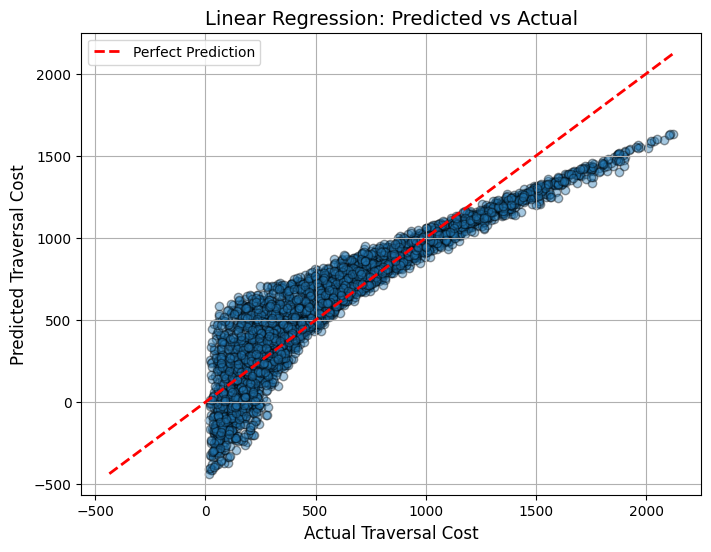

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(y_testing, y_prediction, alpha=0.4, edgecolor="k")

# Plot y=x reference line
max_val = max(max(y_testing), max(y_prediction))
min_val = min(min(y_testing), min(y_prediction))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Traversal Cost", fontsize=12)
plt.ylabel("Predicted Traversal Cost", fontsize=12)
plt.title("Linear Regression: Predicted vs Actual", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()




POLYNOMIAL REGRESSION




In [12]:
from sklearn.preprocessing import PolynomialFeatures 

poly = PolynomialFeatures(degree=4, include_bias=False)
x_training_poly = poly.fit_transform(x_training)
x_testing_poly = poly.transform(x_testing)

scaler_poly = StandardScaler()
x_training_poly = scaler_poly.fit_transform(x_training_poly)
x_testing_poly = scaler_poly.transform(x_testing_poly)

lr_poly = LinearRegression()
lr_poly.fit(x_training_poly, y_training)
y_prediction_poly = lr_poly.predict(x_testing_poly)

In [13]:
mae_poly = mean_absolute_error(y_testing, y_prediction_poly)
mse_poly = mean_squared_error(y_testing, y_prediction_poly)
rmse_poly = np.sqrt(mse_poly)

print("MAE: ", mae_poly)
print("MSE: ", mse_poly)
print("RMSE: ", rmse_poly)

MAE:  0.4368401781869319
MSE:  0.30098051361466166
RMSE:  0.5486169097053623


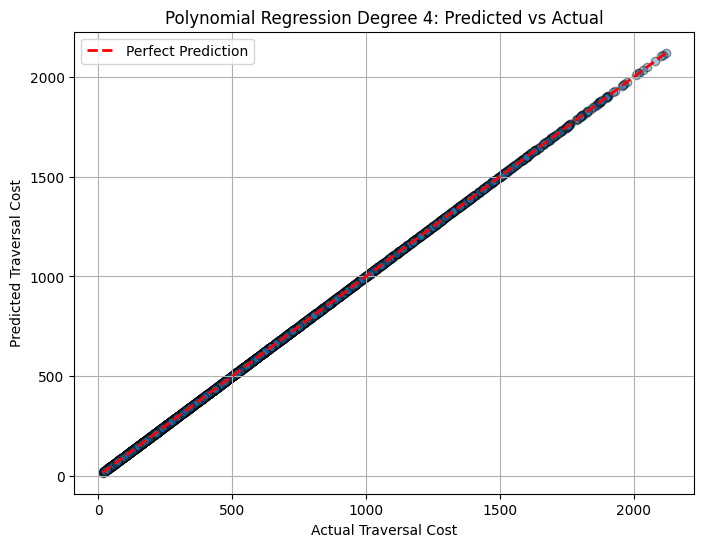

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_testing, y_prediction_poly, alpha=0.4, edgecolor="k")

max_val = max(max(y_testing), max(y_prediction_poly))
min_val = min(min(y_testing), min(y_prediction_poly))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Traversal Cost")
plt.ylabel("Predicted Traversal Cost")
plt.title("Polynomial Regression Degree 4: Predicted vs Actual")
plt.grid(True)
plt.legend()
plt.show()


In [15]:
print("Train R2:", lr_poly.score(x_training_poly, y_training))
print("Test R2:", lr_poly.score(x_testing_poly, y_testing))


Train R2: 0.9999989113340068
Test R2: 0.9999984105070622


In [16]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(lr_poly, x_training_poly, y_training, cv=5, scoring='neg_mean_squared_error')
print("CV RMSE:", np.mean(np.sqrt(-scores)))


CV RMSE: 0.5485621264282748


In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.model_selection import cross_val_score

y_train_pred_poly = lr_poly.predict(x_training_poly)
train_mse = mean_squared_error(y_training, y_train_pred_poly)
train_rmse = np.sqrt(train_mse)

y_test_pred_poly = lr_poly.predict(x_testing_poly)
test_mse = mean_squared_error(y_testing, y_test_pred_poly)
test_rmse = np.sqrt(test_mse)

cv_scores = cross_val_score(
    lr_poly, 
    x_training_poly, 
    y_training, 
    cv=5, 
    scoring='neg_mean_squared_error'
)
cv_rmse = np.mean(np.sqrt(-cv_scores))

print(f"Training RMSE: {train_rmse}")
print(f"Test RMSE:     {test_rmse}")
print(f"CV RMSE:       {cv_rmse}")


Training RMSE: 0.46279542650578875
Test RMSE:     0.5486169097053623
CV RMSE:       0.5485621264282748


Neural Network

In [19]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(264, activation='relu', input_shape=(x_training.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    x_training, y_training,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=0
)

y_pred_nn = model.predict(x_testing, verbose=0).flatten()

mae_nn = mean_absolute_error(y_testing, y_pred_nn)
mse_nn = mean_squared_error(y_testing, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)

print("Neural Network Performance:")
print("MAE:", mae_nn)
print("MSE:", mse_nn)
print("RMSE:", rmse_nn)


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Performance:
MAE: 2.786995546203907
MSE: 13.007489779486457
RMSE: 3.6065897714442734


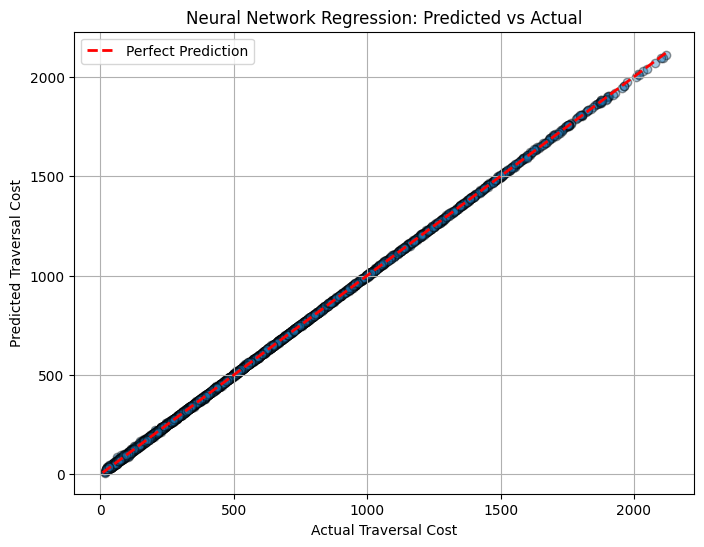

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_testing, y_pred_nn, alpha=0.4, edgecolor="k")

# Diagonal reference line (perfect predictions)
max_val = max(max(y_testing), max(y_pred_nn))
min_val = min(min(y_testing), min(y_pred_nn))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Traversal Cost")
plt.ylabel("Predicted Traversal Cost")
plt.title("Neural Network Regression: Predicted vs Actual")
plt.grid(True)
plt.legend()
plt.show()


In [37]:
dg = pd.read_csv("provided_grid.csv")

dg_encoded = pd.get_dummies(
    dg,
    columns=['type_of_terrain', 'zone_classification', 'time_of_day'],
    drop_first=True
)

if "traversal_cost" in dg_encoded.columns:
    dg_encoded = dg_encoded.drop(columns=["traversal_cost"])

dg_encoded = dg_encoded[x_training.columns]

dg_encoded[numeric_columns] = scaler.transform(dg_encoded[numeric_columns])

X_new_poly = poly.transform(dg_encoded)

X_new_poly_scaled = scaler_poly.transform(X_new_poly)

y_new_predictions = lr_poly.predict(X_new_poly_scaled)

dg["predicted_traversal_cost"] = y_new_predictions

dg.to_csv("Estimated_grid.csv", index=False)

print("Prediction range:",
      y_new_predictions.min(),
      y_new_predictions.max())

print(dg[["predicted_traversal_cost"]].describe())


Prediction range: 12.011354110549519 2224.327036121683
       predicted_traversal_cost
count                400.000000
mean                 583.550110
std                  475.623576
min                   12.011354
25%                  211.475916
50%                  428.220717
75%                  860.835381
max                 2224.327036


In [22]:
import pandas as pd

estimated_grid = pd.read_csv("Estimated_grid.csv")

print("=== Dataset Shape ===")
print(estimated_grid.shape)

print("\n=== Column Names ===")
print(estimated_grid.columns.tolist())

print("\n=== First 5 Rows ===")
print(estimated_grid.head())

print("\n=== Column Info ===")
print(estimated_grid.info())

print("\n=== Summary Statistics ===")
print(estimated_grid.describe())

print("\n=== Missing Values ===")
print(estimated_grid.isnull().sum())

print("\n=== Duplicate Rows ===")
print(estimated_grid.duplicated().sum())

print("\n=== Predicted Traversal Cost Overview ===")
print("Min:", estimated_grid["predicted_traversal_cost"].min())
print("Max:", estimated_grid["predicted_traversal_cost"].max())
print("Mean:", estimated_grid["predicted_traversal_cost"].mean())
print("Median:", estimated_grid["predicted_traversal_cost"].median())


=== Dataset Shape ===
(400, 11)

=== Column Names ===
['elevation', 'avg_traffic_speed', 'pollution_level', 'population_density', 'road_quality_index', 'proximity_main_roads', 'weather_condition_index', 'type_of_terrain', 'zone_classification', 'time_of_day', 'predicted_traversal_cost']

=== First 5 Rows ===
   elevation  avg_traffic_speed  pollution_level  population_density  \
0  37.454012          10.312387       212.171590         3791.315980   
1  95.071431          90.255291        45.761713          122.934582   
2  73.199394          50.525237       172.886508          110.617758   
3  59.865848          82.645747       182.014514         1618.051096   
4  15.601864          32.004960       127.239201         2443.215952   

   road_quality_index  proximity_main_roads  weather_condition_index  \
0            2.726806            261.705684                 4.065437   
1            3.910344            246.978799                 1.645407   
2            3.039908            906.2545

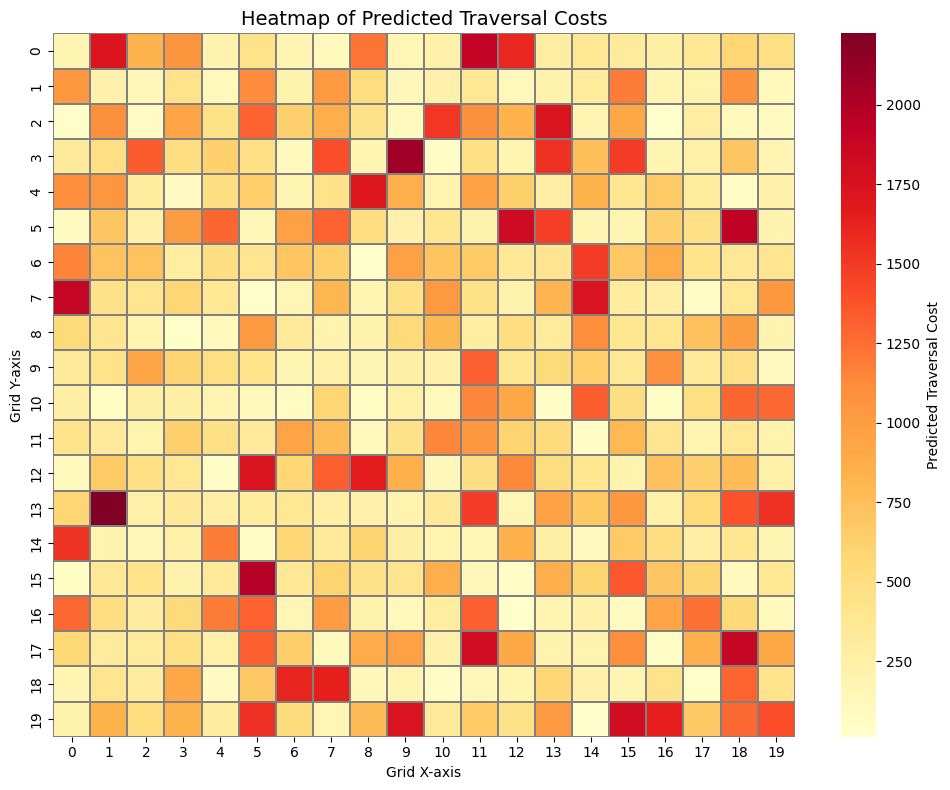

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

dg = pd.read_csv("Estimated_grid.csv")

num_cells = len(dg)
grid_size = int(np.sqrt(num_cells))

if grid_size * grid_size != num_cells:
    raise ValueError("Grid is not square — cannot reshape safely")

cost_grid = dg["predicted_traversal_cost"].values.reshape(
    (grid_size, grid_size)
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cost_grid,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "Predicted Traversal Cost"},
    annot=False
)

plt.title("Heatmap of Predicted Traversal Costs", fontsize=14)
plt.xlabel("Grid X-axis")
plt.ylabel("Grid Y-axis")
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
import numpy as np
import heapq
from collections import deque

dg = pd.read_csv("Estimated_grid.csv")

N = int(np.sqrt(len(dg)))
cost_grid = dg["predicted_traversal_cost"].values.reshape(N, N)

start = (0, 0)
goal = (N-1, N-1)

MOVES = [(-1,0), (1,0), (0,-1), (0,1)]

def in_bounds(x, y):
    return 0 <= x < N and 0 <= y < N


In [25]:
def dfs(start, goal):
    stack = [(start, 0)]
    visited = set()

    while stack:
        (x, y), cost = stack.pop()

        if (x, y) in visited:
            continue
        visited.add((x, y))

        if (x, y) == goal:
            return cost, len(visited)

        for dx, dy in MOVES:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny):
                stack.append(((nx, ny), cost + cost_grid[nx][ny]))

    return np.inf, len(visited)


In [26]:
def bfs(start, goal):
    queue = deque([(start, 0)])
    visited = set([start])

    while queue:
        (x, y), cost = queue.popleft()

        if (x, y) == goal:
            return cost, len(visited)

        for dx, dy in MOVES:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny) and (nx, ny) not in visited:
                visited.add((nx, ny))
                queue.append(((nx, ny), cost + cost_grid[nx][ny]))

    return np.inf, len(visited)


In [27]:
def dijkstra(start, goal):
    pq = [(0, start)]
    visited = set()
    costs = {start: 0}

    while pq:
        cost, (x, y) = heapq.heappop(pq)

        if (x, y) in visited:
            continue
        visited.add((x, y))

        if (x, y) == goal:
            return cost, len(visited)

        for dx, dy in MOVES:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny):
                new_cost = cost + cost_grid[nx][ny]
                if (nx, ny) not in costs or new_cost < costs[(nx, ny)]:
                    costs[(nx, ny)] = new_cost
                    heapq.heappush(pq, (new_cost, (nx, ny)))

    return np.inf, len(visited)


In [36]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])  # Manhattan distance

def astar(start, goal):
    pq = [(0, start)]
    visited = set()
    g_cost = {start: 0}

    while pq:
        _, (x, y) = heapq.heappop(pq)

        if (x, y) in visited:
            continue
        visited.add((x, y))

        if (x, y) == goal:
            return g_cost[(x, y)], len(visited)

        for dx, dy in MOVES:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny):
                tentative_g = g_cost[(x, y)] + cost_grid[nx][ny]
                if (nx, ny) not in g_cost or tentative_g < g_cost[(nx, ny)]:
                    g_cost[(nx, ny)] = tentative_g
                    f = tentative_g + heuristic((nx, ny), goal)
                    heapq.heappush(pq, (f, (nx, ny)))

    return np.inf, len(visited)


In [29]:
results = {
    "DFS": dfs(start, goal),
    "BFS": bfs(start, goal),
    "Dijkstra": dijkstra(start, goal),
    "A*": astar(start, goal)
}

for algo, (cost, visited) in results.items():
    print(f"{algo}:")
    print(f"  Total Path Cost = {cost:.2f}")
    print(f"  Nodes Visited   = {visited}\n")


DFS:
  Total Path Cost = 217865.00
  Nodes Visited   = 381

BFS:
  Total Path Cost = 28347.05
  Nodes Visited   = 400

Dijkstra:
  Total Path Cost = 12863.46
  Nodes Visited   = 400

A*:
  Total Path Cost = 12863.46
  Nodes Visited   = 400

